In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style='darkgrid')
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(10,10)



In [2]:
data_honey = pd.read_csv("US_honey_dataset_updated.csv")
data_honey

,index,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [3]:
# droping the index column from dataset
data_honey.drop(columns=['index'] , inplace=True)
data_honey.head()


,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [4]:
data_honey.shape

(1115, 8)

In [5]:
# all columns
data_honey.columns

Index(['state', 'colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='object')

In [6]:
# checking dtypes of the columns
data_honey.dtypes

state                   object
colonies_number          int64
yield_per_colony         int64
production               int64
stocks                   int64
average_price          float64
value_of_production      int64
year                     int64
dtype: object

In [7]:
# checking if there is any null value

data_honey.isna().sum()

state                  0
colonies_number        0
yield_per_colony       0
production             0
stocks                 0
average_price          0
value_of_production    0
year                   0
dtype: int64

In [8]:
# no of unique state in dataset
len(data_honey.state.unique())

44

In [9]:
# Finding over all top state in production of honey
max_production = data_honey.groupby(['state']).production.sum()
max_production = max_production.sort_values(ascending=False)
max_production

state
NorthDakota      513742000
California       423876000
SouthDakota      355726000
Florida          280934000
Montana          197173000
Minnesota        176581000
Texas            129441000
Michigan         101063000
Wisconsin         99909000
Idaho             87188000
NewYork           78444000
Nebraska          63655000
Louisiana         60568000
Georgia           57426000
Washington        53238000
Arkansas          51846000
Iowa              48607000
Wyoming           43921000
Oregon            43789000
Arizona           38844000
Colorado          32660000
Ohio              22485000
Pennsylvania      21370000
Mississippi       21235000
Utah              20369000
Missouri          17904000
Hawaii            15420000
Alabama           14467000
Kansas            14138000
NewMexico         10082000
Illinois           9864000
Indiana            9686000
NorthCarolina      8909000
Nevada             7399000
Vermont            7032000
NewJersey          6913000
Tennessee          685

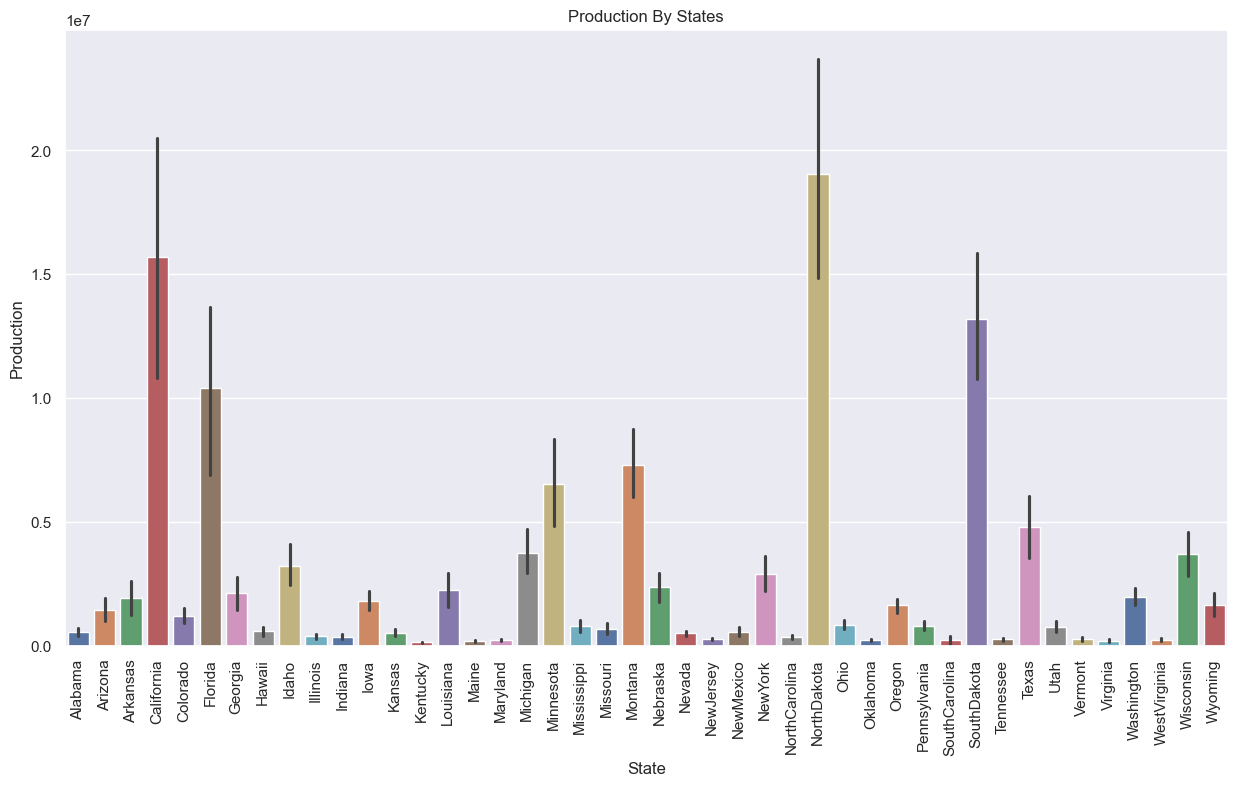

In [10]:
# barplot to know the production of each state over the years.

plt.figure(figsize=(15,8))
sns.barplot(x='state', y='production', data=data_honey,palette='deep')
plt.xticks(rotation=90)
plt.title('Production By States')
plt.xlabel('State')
plt.ylabel('Production')

plt.show()

In [11]:
# Group by state and find the row with the highest production in each state

highest_production = data_honey.loc[data_honey.groupby('state')['production'].idxmax()].sort_values(by='production' , ascending=False).reset_index()

# Display the state, year, and production for the highest values

print(highest_production[['state', 'year', 'production']])

            state  year  production
0      California  1995    39060000
1     NorthDakota  2008    35100000
2     SouthDakota  2000    28435000
3         Florida  1996    25200000
4         Montana  1998    14030000
5       Minnesota  1995    13530000
6           Texas  1997     9964000
7        Michigan  1995     8924000
8       Wisconsin  1998     8099000
9           Idaho  1997     7680000
10        NewYork  2002     5880000
11       Arkansas  2001     5655000
12      Louisiana  1999     5472000
13        Georgia  1996     5100000
14       Nebraska  1996     4875000
15        Arizona  1995     4108000
16           Iowa  1998     3900000
17        Wyoming  2000     3627000
18     Washington  1995     3540000
19         Oregon  1996     3245000
20       Colorado  1995     2700000
21       Missouri  1997     1848000
22           Ohio  1997     1760000
23           Utah  1998     1740000
24   Pennsylvania  2004     1620000
25    Mississippi  2007     1575000
26         Hawaii  1997     

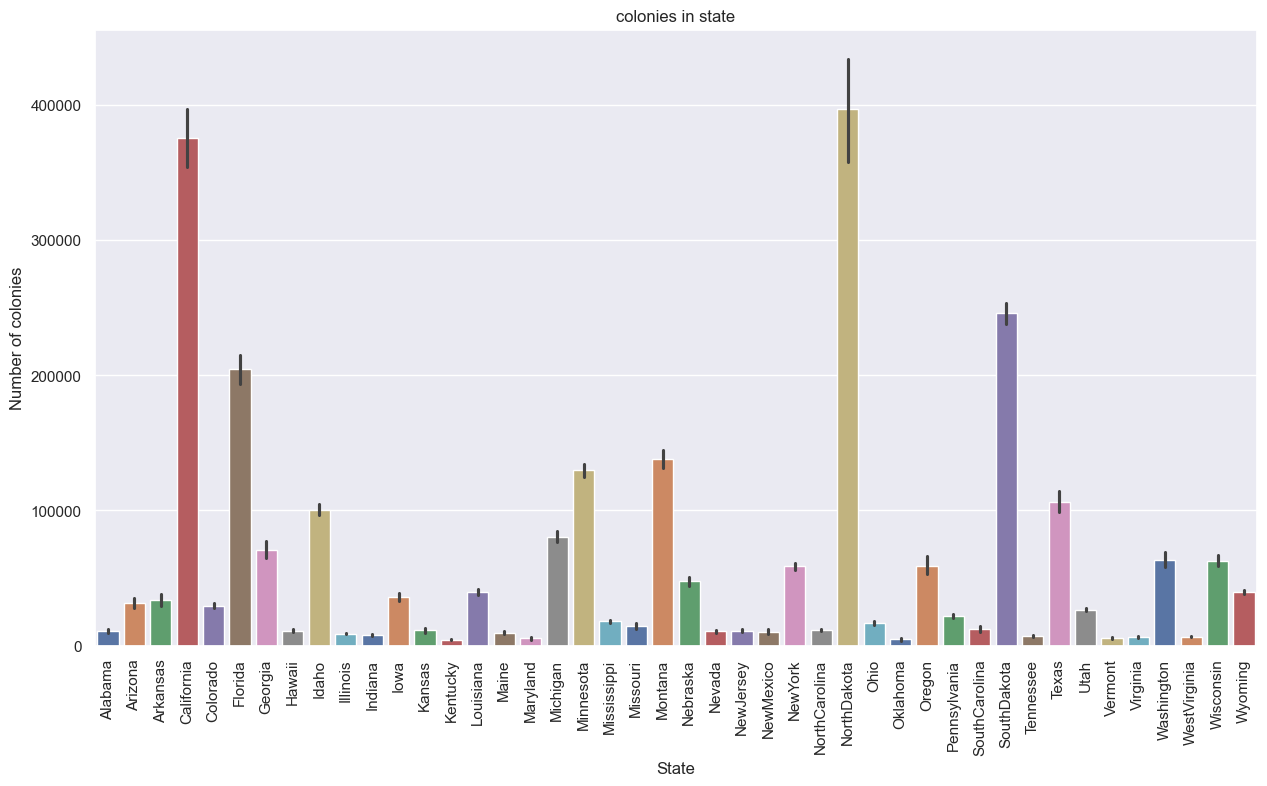

In [12]:
# barplot to find the state with more no of colonies.

plt.figure(figsize=(15,8))
sns.barplot(x='state', y='colonies_number', data=data_honey, palette='deep')
plt.xticks(rotation=90)
plt.title('colonies in state')
plt.xlabel('State')
plt.ylabel('Number of colonies')

plt.show()

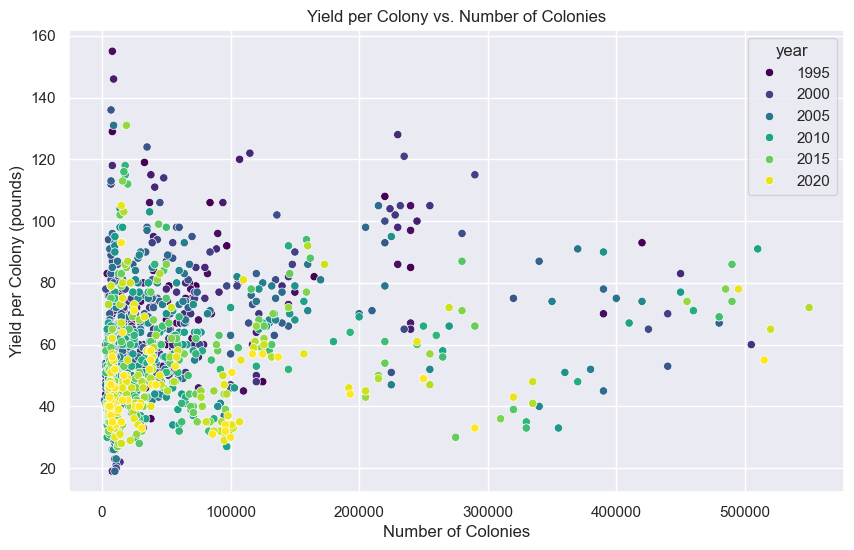

In [13]:
# plot to find the relationship between no of colonies and yield per colonies.

plt.figure(figsize=(10,6))
sns.scatterplot(x='colonies_number', y='yield_per_colony', data=data_honey, hue='year', palette='viridis')
plt.title('Yield per Colony vs. Number of Colonies')
plt.xlabel('Number of Colonies')
plt.ylabel('Yield per Colony (pounds)')
plt.grid(True)
plt.show()

---

By looking at above graph we can infer that *Yield per colonies have declined over the year* if we take *eg 1995,2000* we can see point higher up on y axis.
Even though there is an incerease in no of colonies but yield has not shown improvement.

---


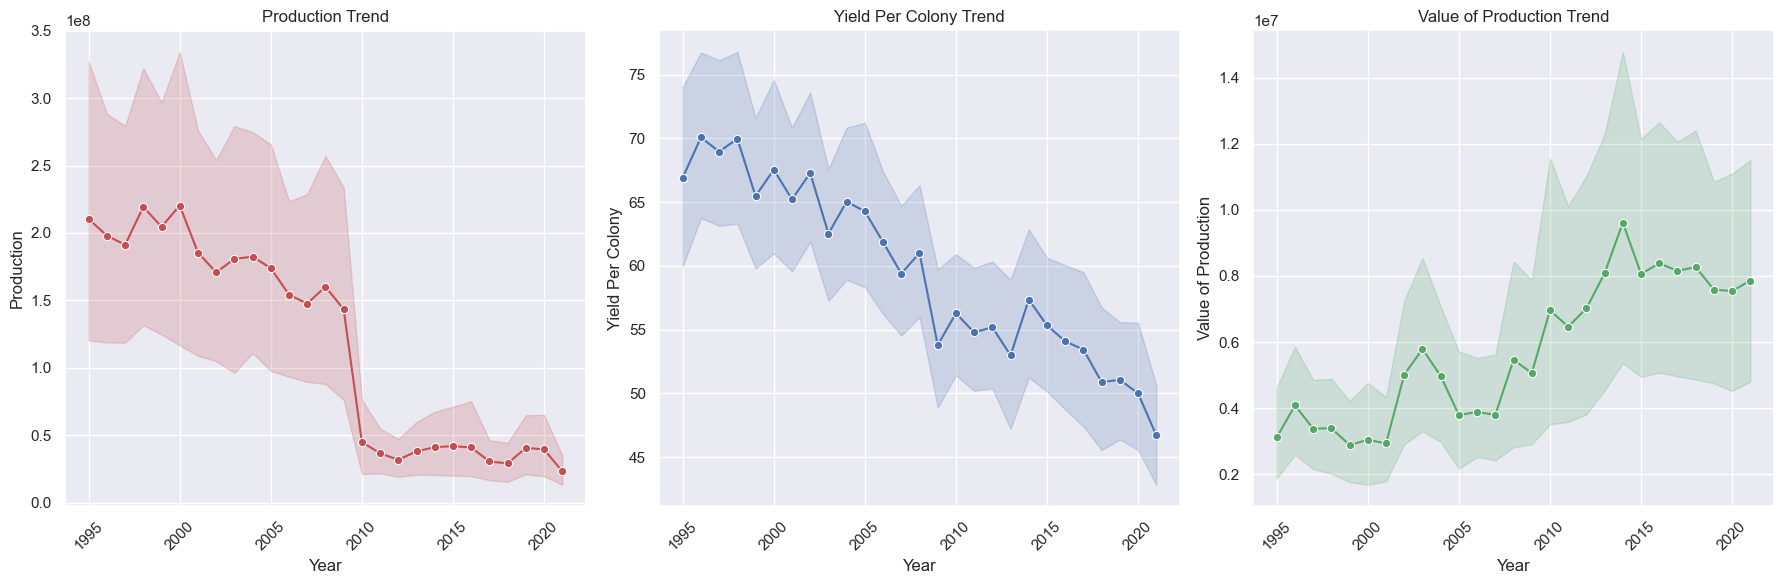

In [14]:
# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Line plot for Honey Production Trend
sns.lineplot(x='year', y='production', data=data_honey, estimator='sum', color='r', marker='o', ax=axes[0])
axes[0].set_title('Production Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Production')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# Line plot for Yield Per Colony
sns.lineplot(x='year', y='yield_per_colony', data=data_honey, color='b', marker='o', ax=axes[1])
axes[1].set_title('Yield Per Colony Trend')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Yield Per Colony')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

# Line plot for Value of Production
sns.lineplot(x='year', y='value_of_production', data=data_honey, marker='o', dashes=False, color='g', ax=axes[2])
axes[2].set_title('Value of Production Trend')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Value of Production')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True)

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

---

##### From looking at above 3 graph we see cleary that production of honey and Yield of honey have have significantly decline post 2006-2007.
#####  value_of_production have seen decline betwwen 2005-2008 but increased from 2010 onwards.


---

In [15]:
# Aggregate honey production per state for time periods: Before 2010

data_before_2010  = data_honey[data_honey['year']<2010]
max_production_per_state = data_before_2010.groupby('state')['production'].max().sort_values(ascending=False).reset_index().head(20)

#max_production_per_state = max_production_per_state.sort_values('production' , ascending=False)
#print(max_production_per_state)

In [16]:
# Aggregate honey production per state for time periods: After 2010

data_after_2010  = data_honey[data_honey['year']>=2010]
max_production_after_2010 = data_after_2010.groupby('state')['production'].max().sort_values(ascending=False).reset_index().head(20)


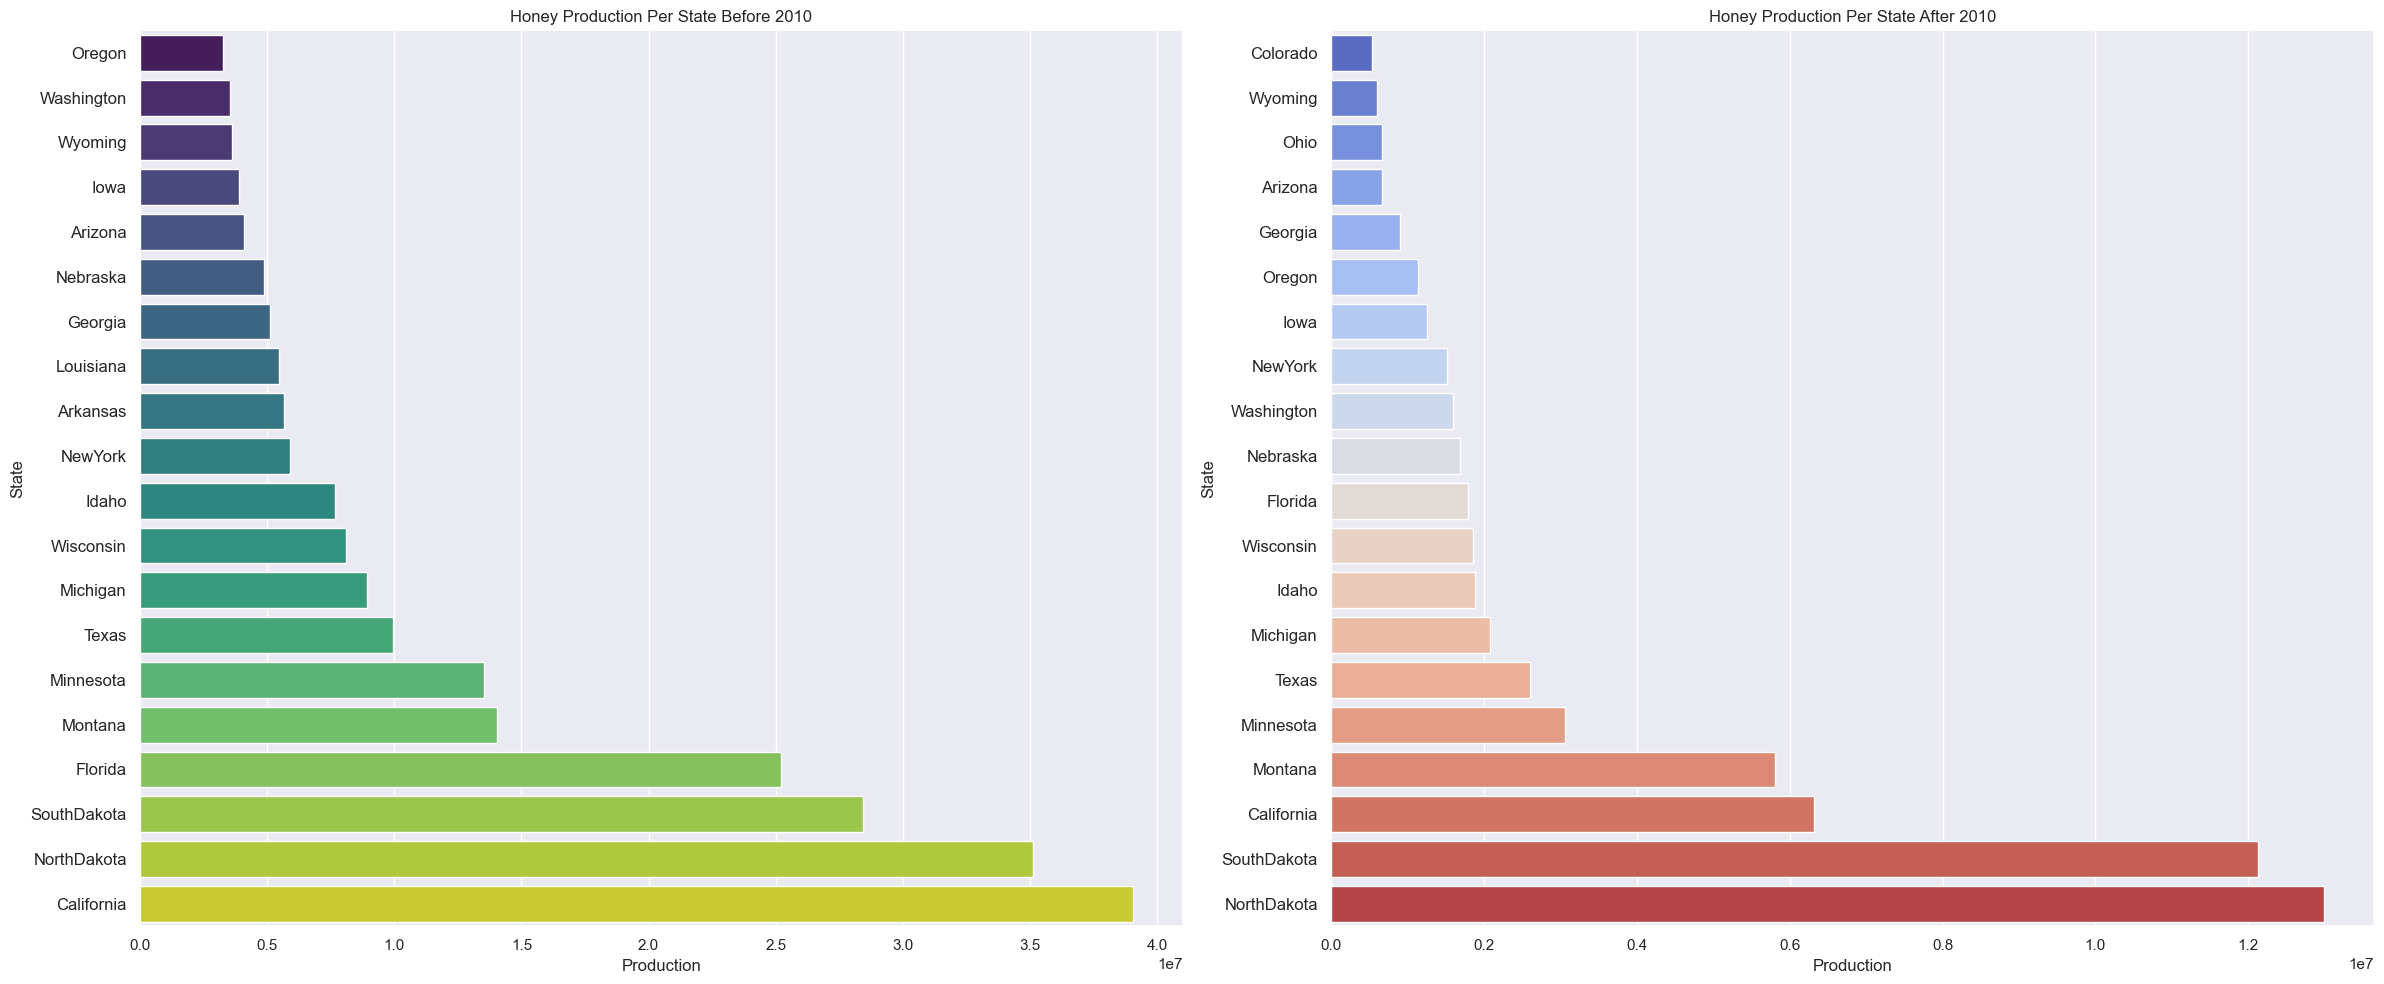

In [17]:
# Create a figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Sorting the data for better visualization
max_production_per_state = max_production_per_state.sort_values(by="production", ascending=True)
max_production_after_2010 = max_production_after_2010.sort_values(by="production", ascending=True)

# Bar plot for honey production before 2010
sns.barplot(x='production', y='state', data=max_production_per_state, palette='viridis', ax=axes[0])
axes[0].set_xlabel('Production')
axes[0].set_ylabel('State')
axes[0].set_title('Honey Production Per State Before 2010')
axes[0].tick_params(axis='y', labelsize=12)

# Bar plot for honey production after 2010
sns.barplot(x='production', y='state', data=max_production_after_2010, palette='coolwarm', ax=axes[1])
axes[1].set_xlabel('Production')
axes[1].set_ylabel('State')
axes[1].set_title('Honey Production Per State After 2010')
axes[1].tick_params(axis='y', labelsize=12)


plt.tight_layout()
plt.show()


---
###### Before 2010:
* California was the top producer of honey follwed by Northdakota, Southdakota and Florida.

###### Post 2010:
*  California saw significant decline in production though it only fall 2 position down but 
production decline in numbers is huge, top producer are NorthDakota and SouthDakota.

* Florida also seen significant decline in production it to 9th position from top 3.
---

In [18]:
# Aggregate honey production per state for two time periods: Before and After 2010
production_before_2010 = data_honey[data_honey["year"] < 2010].groupby("state")["production"].sum()
production_after_2010 = data_honey[data_honey["year"] >= 2010].groupby("state")["production"].sum()

# Calculate the percentage decline in production per state
decline_percentage = ((production_before_2010 - production_after_2010) / production_before_2010) * 100

# Remove states with missing values and sort by decline percentage
decline_percentage = decline_percentage.dropna().sort_values(ascending=False)

# Display top 10 states with the highest production decline
decline_percentage.head(20)


state
Florida          95.802178
Arkansas         95.780650
Alabama          95.778402
NewMexico        95.771736
Missouri         94.725701
Mississippi      94.631072
Louisiana        92.996961
Georgia          92.349798
Utah             91.440601
California       91.006428
Wyoming          90.876792
Hawaii           90.170940
Arizona          90.125308
Virginia         88.704104
Kansas           88.457594
WestVirginia     87.742952
SouthCarolina    87.529880
Minnesota        87.414723
Texas            85.577017
Idaho            85.422170
Name: production, dtype: float64

---
* As we saw in above graphs florida saw 95.80% decline and  California saw 91.06% decline in honey production.
* Minnesota and Texas aslo saw significant decline .
---

In [19]:
numerical_cols = data_honey.select_dtypes(include = ['int64','float']).columns

numerical_cols

Index(['colonies_number', 'yield_per_colony', 'production', 'stocks',
       'average_price', 'value_of_production', 'year'],
      dtype='object')

In [20]:
colunms_outliers = data_honey[['yield_per_colony','production','stocks','average_price', 'value_of_production']]

In [21]:
# lets see if there are na outliers:
def UNA_outliers(data, var_group):

    for col in var_group:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1 

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 - 1.5 * IQR

        outliers_high = (data[col] > upper_bound).sum()
        outliers_low = (data[col] < lower_bound).sum()

        plt.figure(figsize = (6,4))
        sns.boxplot(y=data[col], color='skyblue')
        plt.title(f"Boxplot pf {col}")

        plt.figtext(0.15, -0.2, f"\nLower Bound: {lower_bound : .2f}, Upper Bound : {upper_bound: .2f}\nOutliers Below: {outliers_low : .2f}, Outliers above: {outliers_high}", 
            fontsize=10, ha='left', bbox=dict(facecolor='white', edgecolor='grey', boxstyle = 'round,pad=0.5'))

        plt.tight_layout
        plt.show()
        

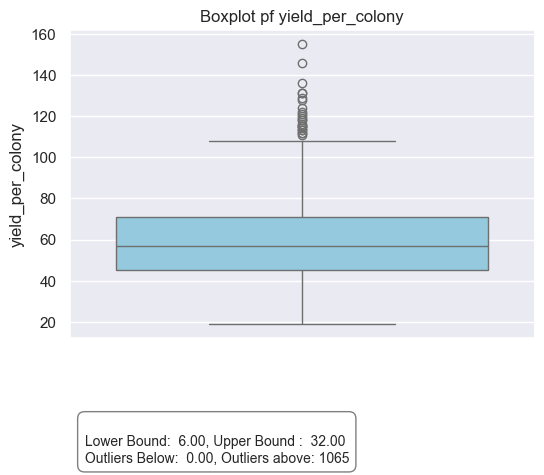

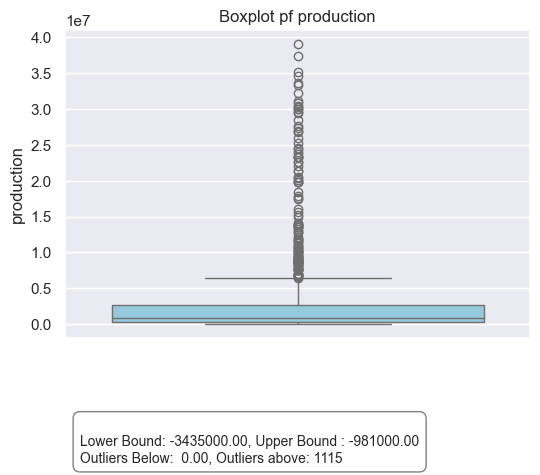

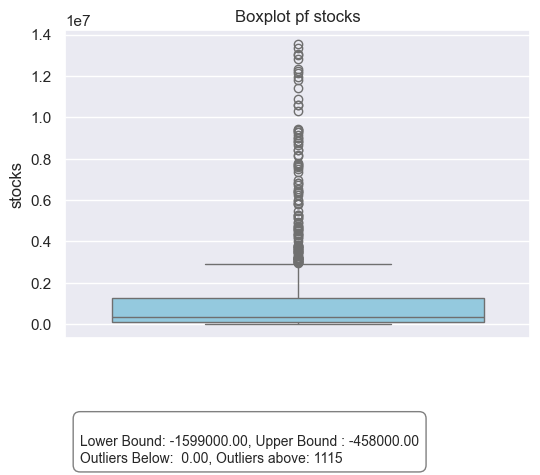

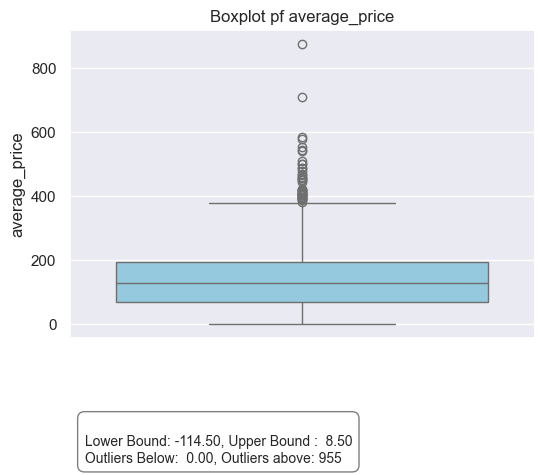

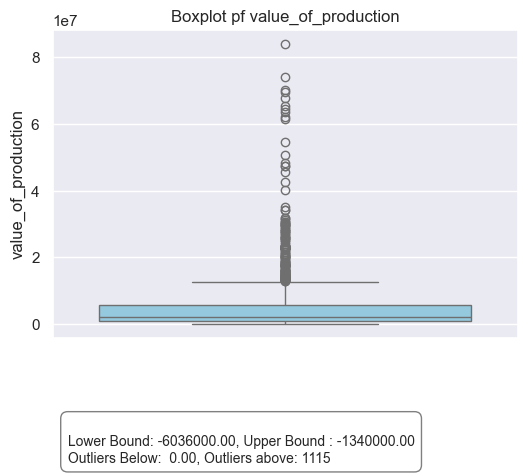

In [22]:
UNA_outliers(data_honey, colunms_outliers)

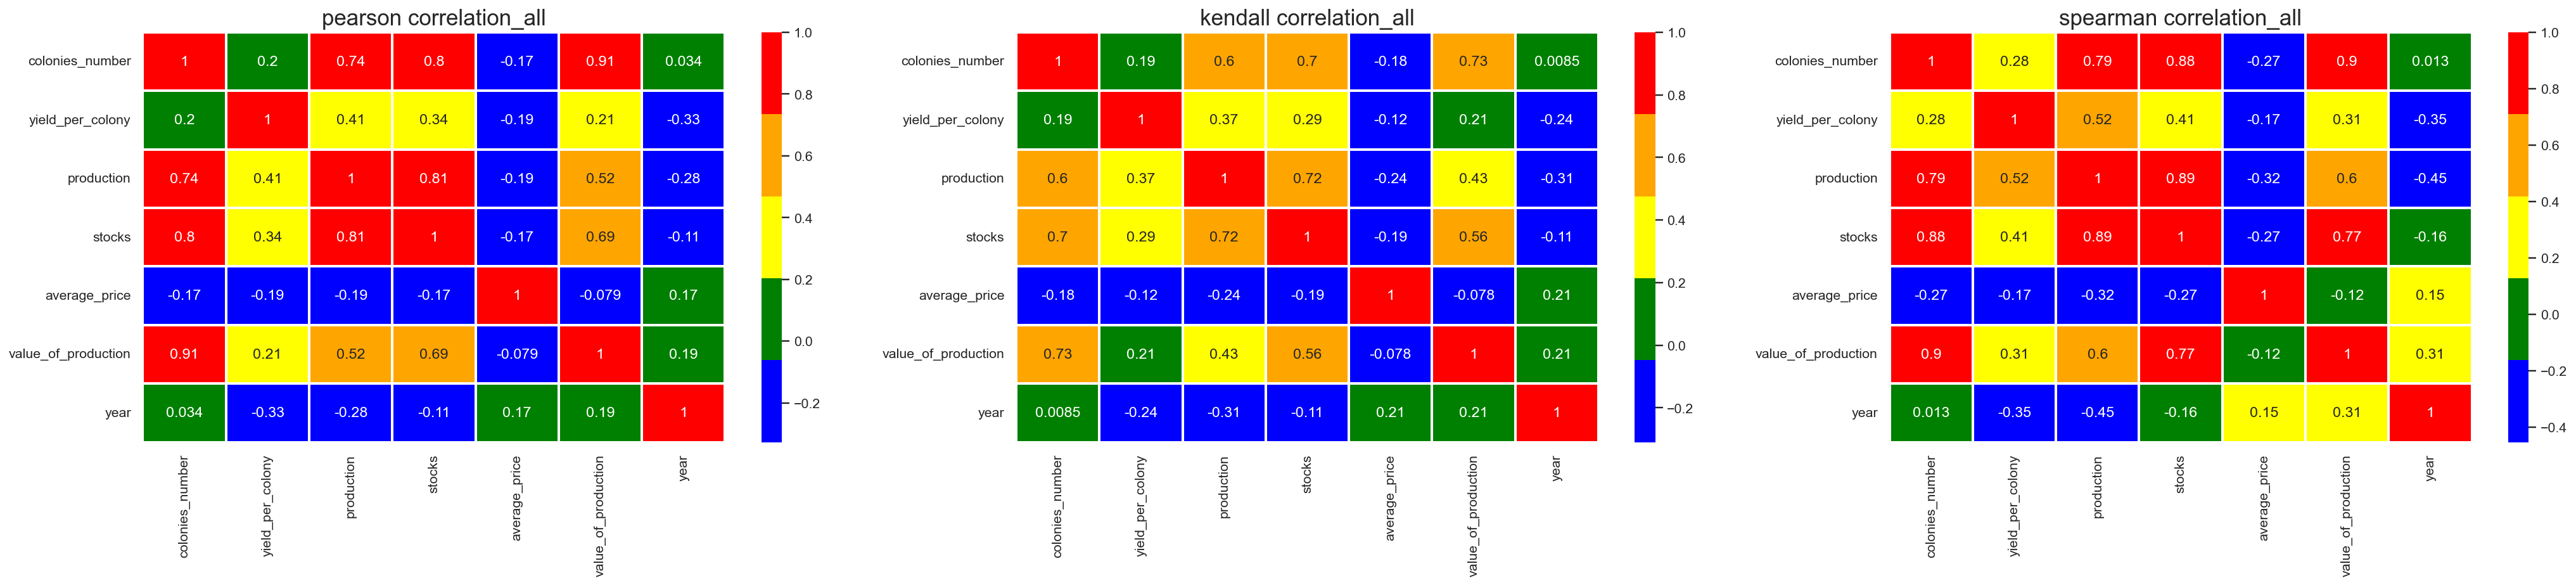

In [25]:
# Plotting heatmap to find coreelation among colunms.
from matplotlib.colors import ListedColormap

plt.figure(figsize = (36,6),dpi= 140)

for j, i in  enumerate(['pearson', 'kendall', 'spearman']):
    plt.subplot(1,3,j+1)
    correlation_all = data_honey.corr(method=i,numeric_only=True)
    cmap = ListedColormap(["blue", "green", "yellow", "orange", "red"])
    sns.heatmap(correlation_all, annot=True, linewidth=2, cmap=cmap)
    plt.title(f"{i} correlation_all", fontsize=18)
plt.tight_layout
plt.show()

---

##### Colonies & Production:

* Strong correlation (+0.74) → More colonies generally lead to higher production.
* Colonies & Economic Value: Even stronger correlation (+0.91), meaning a decline in colonies is a   major factor behind economic losses.

##### Yield per Colony & Production:

* Moderate correlation (+0.41) → Higher colony yield contributes to production, but colony numbers matter more.

##### Price & Production:

* Negative correlation (-0.19) → When production falls, prices tend to increase (likely due to scarcity).

##### Stocks & Production:

* High correlation (+0.81) → Declining production also leads to lower stock levels.

---

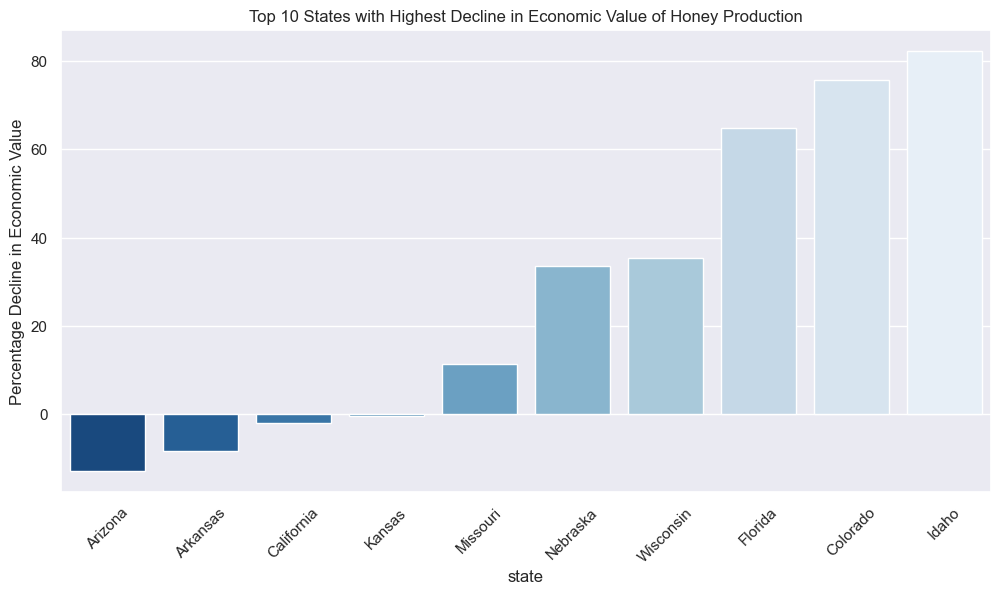

state
Arizona      -12.853562
Arkansas      -8.333333
California    -1.996928
Kansas        -0.370828
Missouri      11.477046
Nebraska      33.579584
Wisconsin     35.457875
Florida       64.922558
Colorado      75.653595
Idaho         82.307692
dtype: float64

In [26]:
# Compute total value of production per state over time
statewise_value_trends = data_honey.groupby(["state", "year"])["value_of_production"].sum().unstack()

# Compute decline rate in economic value
value_decline_rate = (statewise_value_trends.iloc[:, -1] - statewise_value_trends.iloc[:, 0]) / statewise_value_trends.iloc[:, 0] * 100

# Sort states by highest economic value decline
top_value_declining_states = value_decline_rate.sort_values().head(10)

# Plot top states with highest economic loss
plt.figure(figsize=(12, 6))
sns.barplot(x=top_value_declining_states.index, y=top_value_declining_states.values, palette="Blues_r")
plt.xticks(rotation=45)
plt.ylabel("Percentage Decline in Economic Value")
plt.title("Top 10 States with Highest Decline in Economic Value of Honey Production")
plt.show()

top_value_declining_states


#### Z-Test and T-test Hypothesis

In [27]:
from scipy.stats import ttest_ind, zscore

# Split data into two time periods: Early (1995-2005) vs Recent (2011-2021)

early_production = data_honey[(data_honey["year"] >= 1995) & (data_honey["year"] <= 2005)]["production"]
recent_production = data_honey[(data_honey["year"] >= 2011) & (data_honey["year"] <= 2021)]["production"]

# Perform an independent T-Test to check if the means are significantly different
t_stat, t_pval = ttest_ind(early_production, recent_production, equal_var=False)

# Compute Z-score for the decline in production
z_scores = zscore(data_honey["production"])
z_test_value = z_scores.mean()

# Output results
t_stat, t_pval, z_test_value

(10.783755446123422, 1.268351220282885e-24, -5.0980644718213467e-17)

---

* Z-Test shows a negative shift, it reinforces the evidence of an overall downward trend.
  
* A t-value of 10.78 is very high, suggesting that honey production in the recent period (2011-2021) is significantly lower compared to the past (1995-2005).

---
